In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

_NOTEBOOK_DIR = Path.cwd()
_PROJECT_ROOT = _NOTEBOOK_DIR
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Evaluation"))
sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Training"))

from utils import get_engine
from data_prep_batters import (
    load_batter_simulator_data,
    prepare_batter_features,
    train_val_test_split,
    load_batter_encoders,
    PITCH_RESULT_CLASSES,
    RESULT_TO_IDX,
)

In [2]:
_SAVED = _PROJECT_ROOT / "Models" / "Training" / "saved_models"
_MODELS = _PROJECT_ROOT / "Models" / "saved_models"

encoders = load_batter_encoders(_SAVED / "batter_encoders.json")
if encoders is None:
    encoders = load_batter_encoders(_MODELS / "batter_encoders.json")
if encoders is None:
    raise FileNotFoundError("batter_encoders.json not found")

import joblib

clf = xgb.XGBClassifier()
model_path = _SAVED / "batter_pitch_result.json"
if not model_path.exists():
    model_path = _MODELS / "batter_pitch_result.json"
clf.load_model(str(model_path))

cal_path = _SAVED / "batter_pitch_result_calibrated.joblib"
if not cal_path.exists():
    cal_path = _MODELS / "batter_pitch_result_calibrated.joblib"
model = joblib.load(cal_path)
print("Using calibrated model (batter_pitch_result_calibrated.joblib).")

feats = encoders["feats_batter"]
result_to_idx = encoders["result_to_idx"]
idx_to_result = {int(k): v for k, v in encoders["idx_to_result"].items()}
CLASS_NAMES = encoders.get("pitch_result_classes", PITCH_RESULT_CLASSES)
print("Batter model and encoders loaded.")

Using calibrated model (batter_pitch_result_calibrated.joblib).
Batter model and encoders loaded.


In [3]:
engine = get_engine()
df = load_batter_simulator_data(engine)
_, _, test_df = train_val_test_split(df, train_frac=0.8, val_frac=0.1, random_state=42)

X_test, y_test, _ = prepare_batter_features(test_df, cat_encodings=encoders["cat_encodings"], feature_cols=feats)
if np.issubdtype(y_test.dtype, np.integer):
    y_test_idx = y_test.astype(int)
else:
    y_test_idx = y_test.map(lambda r: result_to_idx.get(r, 0)).astype(int)

# Matchup = (batter, pitcher) for real-world evaluation
test_df = test_df.copy()
test_df["matchup"] = list(zip(test_df["batter"], test_df["pitcher"]))
# Indices align: X_test.index == test_df.index
print(f"Test set: {len(X_test)} pitches, {test_df['matchup'].nunique()} unique (batter, pitcher) matchups")

Test set: 34608 pitches, 26141 unique (batter, pitcher) matchups


In [5]:
from sklearn.metrics import accuracy_score, log_loss

y_proba = model.predict_proba(X_test[feats])
weak_idx = encoders.get("weak_class_indices")
if weak_idx is not None and encoders.get("threshold_per_weak_class") is not None:
    # Per-class thresholds (one T per weak class)
    th_per = np.asarray(encoders["threshold_per_weak_class"])
    weak_idx = np.asarray(weak_idx)
    y_pred = np.argmax(y_proba, axis=1)
    for i in range(len(y_pred)):
        best_k, best_p = -1, -1.0
        for j, k in enumerate(weak_idx):
            if y_proba[i, k] >= th_per[j] and y_proba[i, k] > best_p:
                best_p = y_proba[i, k]
                best_k = k
        if best_k >= 0 and best_p >= y_proba[i, y_pred[i]]:
            y_pred[i] = best_k
elif encoders.get("threshold_weak") is not None and weak_idx is not None:
    # Single global threshold (legacy)
    pred = np.argmax(y_proba, axis=1)
    weak_idx = np.asarray(weak_idx)
    weak_proba = y_proba[:, weak_idx]
    weak_argmax_idx = np.argmax(weak_proba, axis=1)
    weak_max = np.max(weak_proba, axis=1)
    T = encoders["threshold_weak"]
    for i in range(len(pred)):
        if weak_max[i] >= T and weak_max[i] >= y_proba[i, pred[i]]:
            pred[i] = weak_idx[weak_argmax_idx[i]]
    y_pred = pred
else:
    y_pred = np.argmax(y_proba, axis=1)
acc = accuracy_score(y_test_idx, y_pred)
ll = log_loss(y_test_idx, y_proba, labels=np.arange(len(CLASS_NAMES)))
print("Overall (all test pitches):")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Log-loss:  {ll:.4f}")

Overall (all test pitches):
  Accuracy:  0.7800
  Log-loss:  0.6650


In [6]:
# Matchup-level evaluation: restrict to matchups with at least N test pitches
import matplotlib.pyplot as plt
min_pitches = 20
groups = test_df.groupby(["batter", "pitcher"])
valid_matchups = [name for name, grp in groups if len(grp) >= min_pitches]

matchup_metrics = []
for (batter, pitcher) in valid_matchups:
    mask = (test_df["batter"] == batter) & (test_df["pitcher"] == pitcher)
    pos = np.flatnonzero(mask.values)
    y_true_m = y_test_idx.iloc[pos].values
    y_pred_m = y_pred[pos]
    y_proba_m = y_proba[pos]
    n = len(y_true_m)
    acc_m = accuracy_score(y_true_m, y_pred_m)
    ll_m = log_loss(y_true_m, y_proba_m, labels=np.arange(len(CLASS_NAMES)))
    matchup_metrics.append({"batter": batter, "pitcher": pitcher, "pitch_count": n, "accuracy": acc_m, "log_loss": ll_m})

matchup_df = pd.DataFrame(matchup_metrics)
if len(matchup_df) == 0:
    print(f"No matchups with >= {min_pitches} pitches.")
else:
    print("Per-matchup accuracy: mean = {:.4f}, median = {:.4f}, std = {:.4f}, min = {:.4f}, max = {:.4f}".format(
        matchup_df["accuracy"].mean(), matchup_df["accuracy"].median(), matchup_df["accuracy"].std(),
        matchup_df["accuracy"].min(), matchup_df["accuracy"].max()))
    print("Per-matchup log loss: mean = {:.4f}, median = {:.4f}, std = {:.4f}".format(
        matchup_df["log_loss"].mean(), matchup_df["log_loss"].median(), matchup_df["log_loss"].std()))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    matchup_df["accuracy"].hist(ax=axes[0], bins=20, edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Accuracy"); axes[0].set_ylabel("Matchups"); axes[0].set_title("Per-matchup accuracy")
    matchup_df["log_loss"].hist(ax=axes[1], bins=20, edgecolor="black", alpha=0.7)
    axes[1].set_xlabel("Log loss"); axes[1].set_ylabel("Matchups"); axes[1].set_title("Per-matchup log loss")
    plt.tight_layout(); plt.show()
    print("\nTop 10 matchups by accuracy:")
    display(matchup_df.nlargest(10, "accuracy")[["batter", "pitcher", "pitch_count", "accuracy", "log_loss"]])
    print("Bottom 10 matchups by accuracy:")
    display(matchup_df.nsmallest(10, "accuracy")[["batter", "pitcher", "pitch_count", "accuracy", "log_loss"]])

No matchups with >= 20 pitches.


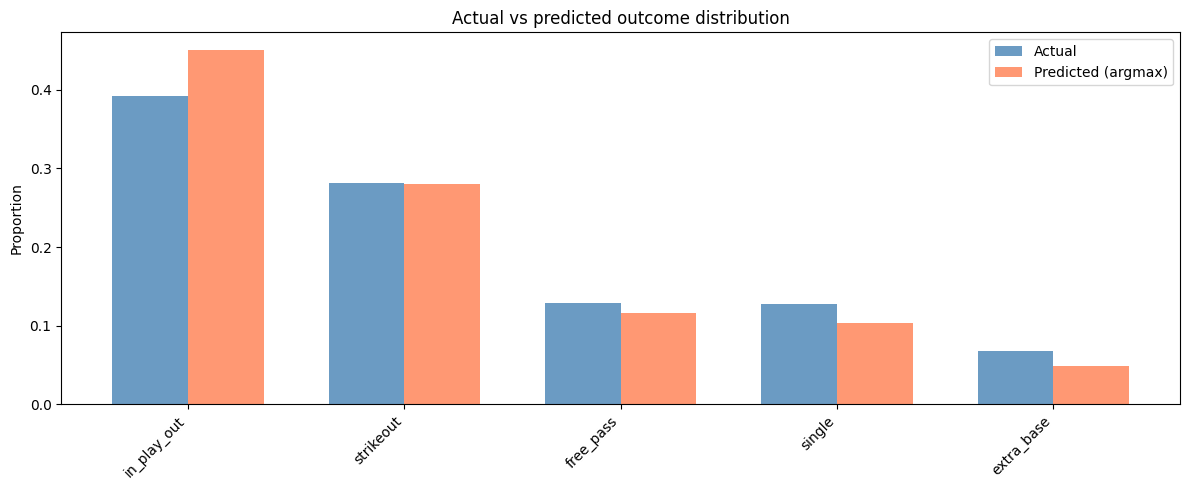

In [7]:
# Real vs predicted outcome distribution
actual_props = pd.Series(y_test_idx).value_counts(normalize=True).reindex(np.arange(len(CLASS_NAMES)), fill_value=0)
pred_props = pd.Series(y_pred).value_counts(normalize=True).reindex(np.arange(len(CLASS_NAMES)), fill_value=0)
mean_proba = pd.Series(y_proba.mean(axis=0), index=np.arange(len(CLASS_NAMES)))

x = np.arange(len(CLASS_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, actual_props.values, width, label="Actual", color="steelblue", alpha=0.8)
ax.bar(x + width/2, pred_props.values, width, label="Predicted (argmax)", color="coral", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Proportion"); ax.set_title("Actual vs predicted outcome distribution")
ax.legend(); plt.tight_layout(); plt.show()

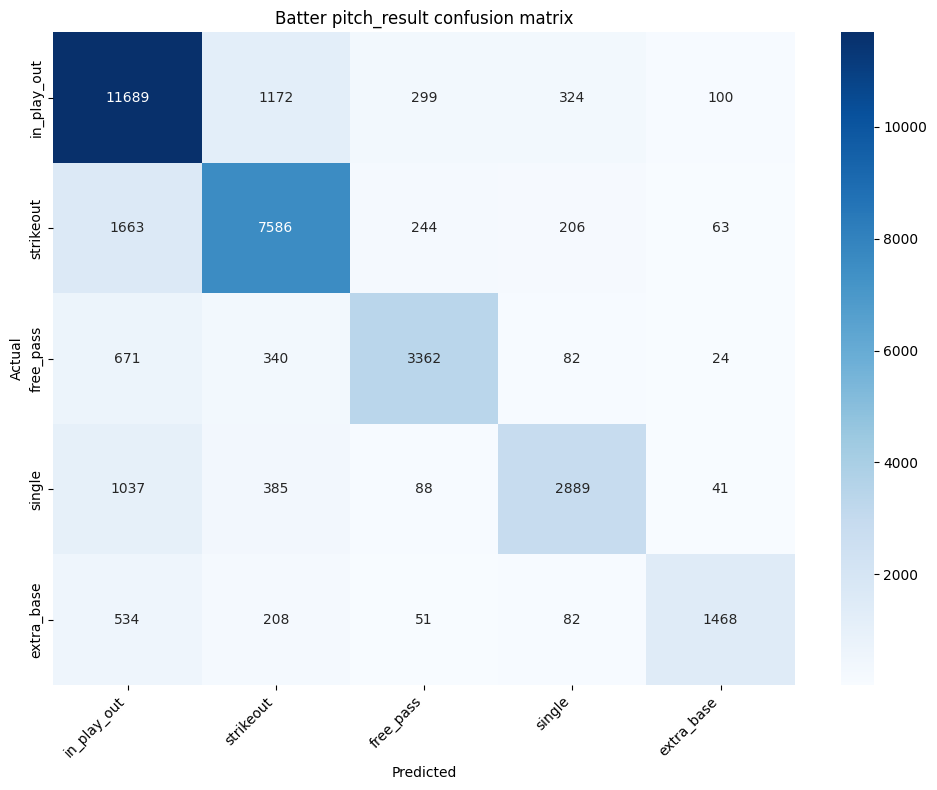

              precision    recall  f1-score   support

 in_play_out       0.75      0.86      0.80     13584
   strikeout       0.78      0.78      0.78      9762
   free_pass       0.83      0.75      0.79      4479
      single       0.81      0.65      0.72      4440
  extra_base       0.87      0.63      0.73      2343

    accuracy                           0.78     34608
   macro avg       0.81      0.73      0.76     34608
weighted avg       0.78      0.78      0.78     34608



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_idx, y_pred, labels=np.arange(len(CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot=True, fmt="d", ax=ax, cmap="Blues")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.title("Batter pitch_result confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(y_test_idx, y_pred, target_names=CLASS_NAMES, zero_division=0))

In [9]:
# Stratified metrics: by count bucket and by pitch type
strat = test_df[["balls", "strikes", "pitch_type"]].copy()
strat["y_true"] = y_test_idx.values
strat["y_pred"] = y_pred

# By count bucket: 0-0, 0-2, 3-2, other
def count_bucket(row):
    b, s = int(row["balls"]), int(row["strikes"])
    if b == 0 and s == 0: return "0-0"
    if b == 0 and s == 2: return "0-2"
    if b == 3 and s == 2: return "3-2"
    return "other"
strat["count_bucket"] = strat.apply(count_bucket, axis=1)
by_count = strat.groupby("count_bucket").apply(lambda g: pd.Series({
    "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
    "log_loss": log_loss(g["y_true"], y_proba[test_df.index.get_indexer(g.index)], labels=np.arange(len(CLASS_NAMES))),
    "n": len(g)
}))
print("Accuracy and log loss by count bucket:")
display(by_count)

# By pitch type
if "pitch_type" in strat.columns:
    by_pitch = strat.groupby("pitch_type").apply(lambda g: pd.Series({
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "n": len(g)
    })).sort_values("n", ascending=False)
    print("\nAccuracy by pitch type:")
    display(by_pitch)

Accuracy and log loss by count bucket:


C:\Users\macia\AppData\Local\Temp\ipykernel_38744\3279053081.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_count = strat.groupby("count_bucket").apply(lambda g: pd.Series({


,accuracy,log_loss,n
count_bucket,,,
0-0,0.751357,0.748735,7923.0
0-2,0.810319,0.559490,2636.0
3-2,0.819111,0.526984,2250.0
other,0.782696,0.661499,21799.0



Accuracy by pitch type:


C:\Users\macia\AppData\Local\Temp\ipykernel_38744\3279053081.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_pitch = strat.groupby("pitch_type").apply(lambda g: pd.Series({


,accuracy,n
pitch_type,,
FF,0.779676,11238.0
SI,0.788002,5184.0
SL,0.775662,5095.0
CH,0.782005,3601.0
FC,0.784825,2570.0
CU,0.765306,2450.0
ST,0.771923,2429.0
FS,0.773820,1123.0
KC,0.805369,596.0


In [10]:
# Calibration (only when using calibrated model)
try:
    _cal = using_calibrated
except NameError:
    _cal = False
if not _cal:
    print("N/A (uncalibrated model).")
else:
    from sklearn.metrics import brier_score_loss
    n_classes = len(CLASS_NAMES)
    brier_per_class = []
    for k in range(n_classes):
        y_bin = (y_test_idx.values == k).astype(int)
        proba_k = y_proba[:, k]
        brier_per_class.append(brier_score_loss(y_bin, proba_k))
    brier_series = pd.Series(brier_per_class, index=CLASS_NAMES)
    print("Brier score per class (lower is better):")
    display(brier_series.sort_values())

Brier score per class (lower is better):


extra_base     0.026860
free_pass      0.040427
single         0.049961
strikeout      0.087058
in_play_out    0.108884
dtype: float64